# Age and Tobacco Usage Trends

# Permissions

Place an `X` in the appropriate bracket below to specify if you would like your group's project to be made available to the public. (Note that student names will be included (but PIDs will be scraped from any groups who include their PIDs).

* [ X ] YES - make available
* [  ] NO - keep private

# Names

- Emre Durmus 
- Annie Phan 
- Carlson Ricardo Salim 
- Yu Xu 
- Safia Mahamed

# Abstract

Our project is focused on investigating the tobacco usage trends among different age groups in the US over time from 2011 to 2016. We wanted to know how much age influences the extent of tobacco usage and the preferences for certain types of tobacco products such as cigarettes and smokeless tobacco. This could help us better understand the patterns behind tobacco usage over time. 

For our data analysis, we employ statistical analyses such as linear regression, correlation and difference in means testing. For the prediction, we use linear regression to determine the impact of age and tobacco type on consumption levels. We wanted to see if there was a statistical significance between age and tobacco usage. Followed by linear regression, Pearson correlation is used to measure the strength of our prior findings and see if there is a true correlation with the results. This is used to see if age is a significant factor in determining tobacco usage and type. We then use difference in means testing to test our prior predictions.

We have ultimately discovered that there is a consistent decrease in tobacco usage across age groups below 65, while those above age 65 exhibited the lowest and relatively constant consumption rates. However, it is important to note that there is a weak correlation between average age and tobacco product usage. It is important to note that there is an association between age and preference for tobacco products. The t-test confirms the statistically significant differences in tobacco product preferences.


# Research Question

How has the ages of tobacco users changed over the years in the US from 2011 to 2016? Is age a significant factor in influencing the preference for certain types of tobacco products, such as cigarettes and Smokeless Tobacco?


## Background and Prior Work

Public Health efforts have been highlighting the threat of tobacco consumption since 1965 with heavily recognized counter-marketing strategies to underline the carcinogenic effects of the chemical. These efforts have consistently been most amplified for smoking products, notably cigarettes. Since then, cigarettes have also been proven to contribute to the 4 main causes of 50% of global mortality, by dramatically increasing risks of Cardiovascular Disease, Chronic Lower Respiratory Disease, and Diabetes (with Cancer as the fourth). 

Despite attempts of legislation and regulation by governments, underage risky behaviors have exposed children and youth to these substances. With a better understanding of the patterns of age-groups using tobacco substances, we can better design interventions and target the most receptive populations to inhibit the continuing growth of the issue. Trends in youth smoking behavior tend to fluctuate substantially, it is important to view this recent trend within a broader time frame. This project aims to study the age trends of tobacco use over the years in the U.S. We hope that models and analysis of tobacco usage among age groups will provide insight into future consumers. This leads us to answer the following questions:

How does tobacco usage vary across age groups and what might explain the differences in usage among age groups? Are there confounding factors impacting tobacco usage?

Can age and other demographic factors accurately predict future consumption of tobacco? How can we mitigate usage? 

As such, we can gain valuable insight to the pattern of use and predict the ages of future consumers. Inference with a regression analysis can then be made to predict patterns of age and type of tobacco use broken down to the categories of Cigarettes or Smokeless Tobacco. As such the measure
The “Total Emissions per Country Code Starter”<a name="cite_ref-1"></a>[<sup>1</sup>](#cite_note-1) model can be used due to the similar nature of data organization, by country and year studied with a central measure to answer the research question at hand) as a basis for the dataset cleaning and sorting. 
The “Exploring Survival on the Titanic”<a name="cite_ref-2"></a>[<sup>2</sup>](#cite_note-2) project uses a similar prediction model based on various factors to do a randomForest test and predict survival or death from the titanic, this code can be replicated for our project to be used based on our variables to predict who of smokers in age groups would turn to Cigarettes vs. Smokeless tobacco as form of Tobacco consumption. 
The “Let's explore how to read and interpret heatmap & correlation map”<a name="cite_ref-3"></a>[<sup>3</sup>](#cite_note-3) post breaks down code on producing heatmaps and correlation maps, which can be effective visualizations for wrangled and manipulated data and to support arguments of correlation.
Finally, the “Heart Disease Prediction Through Logistic Regression”<a name="cite_ref-4"></a>[<sup>4</sup>](#cite_note-4) reinforces the exposure and outcome of cigarette use, offers validity testing methods, and provides effective data visualization methods that can be adopted. 


# Hypothesis


Over the past in the US, there is a significant linear relationship in the ages of tobacco users, with individuals aged 45 years and older increasingly contributing to tobacco usage rates, while the prevalence among younger age groups, defined as individuals aged 18 to 24 years shows a marked decline. This trend can be partially explained by the preference of older age groups for traditional tobacco products such as cigarettes, in contrast to younger age groups that may exhibit different usage patterns or preferences for alternative tobacco or smokeless tobacco.

# Data

Dataset Name: US Tobacco Use Prevalence
  - Link to the dataset: https://www.kaggle.com/datasets/thedevastator/us-tobacco-use-prevalence
  - Number of observations: 3186
  - Number of variables: 8

The dataset tracks tobacco usage across different states, years, age groups in the United States from 2011-2016. The important variables in this dataset are the Year which represents the year of the survey, Tobacco Type which specifies the type of tobacco product, Data Value which is the key metric reporting usage of the specified tobacco type in percentage, and Age which specifies the age group of the respondants. We would preprocess this data by considering missing or duplicated values, and changing some attribute names to make it clearer.

## Dataset US Tobacco Use Prevalence

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import patsy
import statsmodels.api as sm
from scipy.stats import pearsonr
import scipy.stats as stats

In [2]:
# description (extracted from the data source): 
#
# Year: The year in which the data was collected (Numeric)
# State Abbreviation: The abbreviation of the state where the data was collected (String)
# Tobacco Type: The type of tobacco product used (String)
# Data Value: The percentage or number representing prevalence of tobacco use (Numeric)
# Data Value Unit: The unit of measurement for data value (e.g., percentage, number) (String)
# Age: The age group to which the data value corresponds (String)
#
#


df = pd.read_csv('dataset/Week 37 - US Tobacco Use 2011 - 2016.csv')

In [3]:
# Display the first 5 data
df.head()

,index,Year,State Abbreviation,State,Tobacco Type,Data Value,Data Value Unit,Age
0,0,2011,AL,Alabama,Cigarette,30.3,%,18 to 24 Years
1,1,2011,AL,Alabama,Cigarette,28.2,%,25 to 44 Years
2,2,2011,AL,Alabama,Cigarette,26.2,%,45 to 64 Years
3,3,2011,AL,Alabama,Cigarette,10.2,%,65 Years and Older
4,4,2011,AL,Alabama,Cigarette,24.3,%,All Ages


In [4]:
# Check the shape of the dataset
df.shape

(3186, 8)

In [5]:
# Check if there is any empty values
df[df.isnull().any(axis=1)].shape

(0, 8)

In [6]:
# Check if there is any duplicated rows
duplicates = df.duplicated()
num_duplicates = duplicates.sum()
num_duplicates

0

In [7]:
# Some columns have variables that are irrelevant because such values do not offer additional information
# Drop the columns that are not needed for our project
df = df.drop(columns = ['index', 'State Abbreviation', 'Data Value Unit'])

# Rename attribute 'Data Value' to 'Percent_Usage'
df = df.rename(columns={'Data Value': 'Percent_Usage'})

# Rename attribute 'Tobacco Type' to 'Tobacco_Type'
df = df.rename(columns={'Tobacco Type': 'Tobacco_Type'})

# Check the attribute names
df.columns

Index(['Year', 'State', 'Tobacco_Type', 'Percent_Usage', 'Age'], dtype='object')

In [8]:
df.describe()

,Year,Percent_Usage
count,3186.000000,3186.000000
mean,2013.500000,11.285656
std,1.708093,8.558490
min,2011.000000,0.200000
25%,2012.000000,4.000000
50%,2013.500000,8.500000
75%,2015.000000,18.600000
max,2016.000000,38.500000


In [9]:
# Unique years
print(df['Year'].unique())

[2011 2012 2013 2014 2015 2016]


In [10]:
# Unique states
print(df['State'].unique())

['Alabama' 'Alaska' 'Arizona' 'Arkansas' 'California' 'Colorado'
 'Connecticut' 'Delaware' 'District of Columbia' 'Florida' 'Georgia'
 'Guam' 'Hawaii' 'Idaho' 'Illinois' 'Indiana' 'Iowa' 'Kansas' 'Kentucky'
 'Louisiana' 'Maine' 'Maryland' 'Massachusetts' 'Michigan' 'Minnesota'
 'Mississippi' 'Missouri' 'Montana' 'National Median (States and DC)'
 'Nebraska' 'Nevada' 'New Hampshire' 'New Jersey' 'New Mexico' 'New York'
 'North Carolina' 'North Dakota' 'Ohio' 'Oklahoma' 'Oregon' 'Pennsylvania'
 'Puerto Rico' 'Rhode Island' 'South Carolina' 'South Dakota' 'Tennessee'
 'Texas' 'Utah' 'Vermont' 'Virginia' 'Washington' 'West Virginia'
 'Wisconsin' 'Wyoming']


In [11]:
# Unique tabacco type
print(df['Tobacco_Type'].unique())

['Cigarette' 'Smokeless Tobacco']


In [12]:
# Unique percentage values
print(df['Percent_Usage'].unique())

[30.3 28.2 26.2 10.2 24.3  8.6  8.3  5.3  3.9  6.5 21.8 26.3 22.9 12.4
  3.5  2.3  5.9 19.2 23.  20.8  9.  19.3  2.9  1.2  3.  27.1 32.9 29.7
 11.6 27.  10.   9.7  6.   2.5  7.1 13.4 16.4 13.7  6.9  1.7  2.2  0.9
  0.5  1.4 21.6 21.9 17.5  8.8 18.3  5.5  6.3  3.3  1.9  4.5 19.4 21.5
 17.1  8.5  1.5  0.7 30.6 21.4  8.9  3.8  1.   0.8 16.1 25.1 11.   1.3
 20.1 23.4  7.9  4.3  2.1 25.  23.6 10.8 21.2  5.8  4.4  4.  33.9 35.8
 15.1 30.5 12.1 10.4  4.6  7.8 23.2 20.6 16.5  6.6 16.8  2.4 18.2 21.1
 17.3  8.4 17.2  1.1  4.8 25.2 24.1 22.6  7.6 20.9  3.6  2.7  2.   3.4
 29.  31.  11.5 25.6  6.7  5.  20.4  6.4  2.6  1.6  4.2 24.5 27.2 22.5
  9.5 22.   4.1 30.9 37.5  9.2  4.7  6.8 22.8 33.  25.7  5.1  3.7  3.2
 29.2 21.   2.8 19.9 19.1 23.3 16.7 29.5  9.9 24.7 22.7 18.9 31.8 27.3
 26.   8.7  7.5  8.  25.8 31.9 10.1  7.4 24.4 22.1 11.8 10.3 25.5 19.8
 20.   5.6 17.4 26.8 25.3 13.5 21.7 18.   7.3  5.4 19.  17.9 27.5  9.8
 19.5 18.1 24.   5.2 29.1 15.9 30.4 26.6 26.1 31.5 28.6 11.7  9.6 19.7
 27.8 

In [13]:
# Which states have the highest and lowest rates of tobacco use?
# sort states by tobacco use (all age groups, both tobacco types)

df_all_age = df[df['Age'] == 'All Ages']

In [14]:
df_all_age

,Year,State,Tobacco_Type,Percent_Usage,Age
4,2011,Alabama,Cigarette,24.3,All Ages
9,2011,Alabama,Smokeless Tobacco,6.5,All Ages
14,2011,Alaska,Cigarette,22.9,All Ages
19,2011,Alaska,Smokeless Tobacco,5.9,All Ages
24,2011,Arizona,Cigarette,19.3,All Ages
...,...,...,...,...,...
3165,2016,West Virginia,Smokeless Tobacco,8.5,All Ages
3170,2016,Wisconsin,Cigarette,17.1,All Ages
3175,2016,Wisconsin,Smokeless Tobacco,4.4,All Ages
3180,2016,Wyoming,Cigarette,18.9,All Ages


In [15]:
# What are the most commonly used types of tobacco products?

df_all_age[['Percent_Usage', 'Tobacco_Type']].sort_values(by='Percent_Usage', ascending = False)

,Percent_Usage,Tobacco_Type
114,30.5,Cigarette
1707,29.2,Cigarette
184,29.0,Cigarette
505,28.6,Cigarette
715,28.3,Cigarette
...,...,...
3065,1.1,Smokeless Tobacco
951,1.0,Smokeless Tobacco
2003,0.9,Smokeless Tobacco
941,0.7,Smokeless Tobacco


*Here we can see that Cigarette is more commonly used than Smokeless Tobacco*

In [16]:
# first check the counts for each type

print(df['Tobacco_Type'].value_counts(), df_all_age['Tobacco_Type'].value_counts())

Tobacco_Type
Smokeless Tobacco    1596
Cigarette            1590
Name: count, dtype: int64 Tobacco_Type
Smokeless Tobacco    324
Cigarette            318
Name: count, dtype: int64


In [17]:
df_ages = df[df['Age'] != 'All Ages']

df_ages.value_counts('Tobacco_Type')

Tobacco_Type
Cigarette            1272
Smokeless Tobacco    1272
Name: count, dtype: int64

In [18]:
# create two separate df based on type
df_cig = df_ages[df_ages['Tobacco_Type'] == 'Cigarette']
df_st = df_ages[df_ages['Tobacco_Type'] == 'Smokeless Tobacco']

# Display the observations with only Cigarette
df_cig.head(10)

,Year,State,Tobacco_Type,Percent_Usage,Age
0,2011,Alabama,Cigarette,30.3,18 to 24 Years
1,2011,Alabama,Cigarette,28.2,25 to 44 Years
2,2011,Alabama,Cigarette,26.2,45 to 64 Years
3,2011,Alabama,Cigarette,10.2,65 Years and Older
10,2011,Alaska,Cigarette,21.8,18 to 24 Years
11,2011,Alaska,Cigarette,26.3,25 to 44 Years
12,2011,Alaska,Cigarette,22.9,45 to 64 Years
13,2011,Alaska,Cigarette,12.4,65 Years and Older
20,2011,Arizona,Cigarette,19.2,18 to 24 Years
21,2011,Arizona,Cigarette,23.0,25 to 44 Years


In [19]:
# Display the observations with only Smokeless Tobacco
df_st.head(10)

,Year,State,Tobacco_Type,Percent_Usage,Age
5,2011,Alabama,Smokeless Tobacco,8.6,18 to 24 Years
6,2011,Alabama,Smokeless Tobacco,8.3,25 to 44 Years
7,2011,Alabama,Smokeless Tobacco,5.3,45 to 64 Years
8,2011,Alabama,Smokeless Tobacco,3.9,65 Years and Older
15,2011,Alaska,Smokeless Tobacco,8.3,18 to 24 Years
16,2011,Alaska,Smokeless Tobacco,8.3,25 to 44 Years
17,2011,Alaska,Smokeless Tobacco,3.5,45 to 64 Years
18,2011,Alaska,Smokeless Tobacco,2.3,65 Years and Older
25,2011,Arizona,Smokeless Tobacco,3.9,18 to 24 Years
26,2011,Arizona,Smokeless Tobacco,2.9,25 to 44 Years


In [20]:
# create a function that add the percentage of cigarette and smokeless tobacco by age groups

def total_smoker(df1, df2):
    # Merge the two datasets on 'year', 'state', and 'age'
    merged_df = pd.merge(df1, df2, on=['Year', 'State', 'Age'], suffixes=('_df1', '_df2'))
    
    # Add the 'percent_use' columns from both datasets
    merged_df['total_percent_use'] = merged_df['Percent_Usage_df1'] + merged_df['Percent_Usage_df2']
    
    # Create the new dataset with the desired structure
    new_dataset = merged_df[['Year', 'State', 'Age', 'total_percent_use']]
    
    return new_dataset
        

df_smoker = total_smoker(df_cig, df_st)

# This dataset contains the total Percentage Usage of tobacco for each Age group
df_smoker

,Year,State,Age,total_percent_use
0,2011,Alabama,18 to 24 Years,38.9
1,2011,Alabama,25 to 44 Years,36.5
2,2011,Alabama,45 to 64 Years,31.5
3,2011,Alabama,65 Years and Older,14.1
4,2011,Alaska,18 to 24 Years,30.1
...,...,...,...,...
1267,2016,Wisconsin,65 Years and Older,9.4
1268,2016,Wyoming,18 to 24 Years,40.0
1269,2016,Wyoming,25 to 44 Years,37.9
1270,2016,Wyoming,45 to 64 Years,24.4


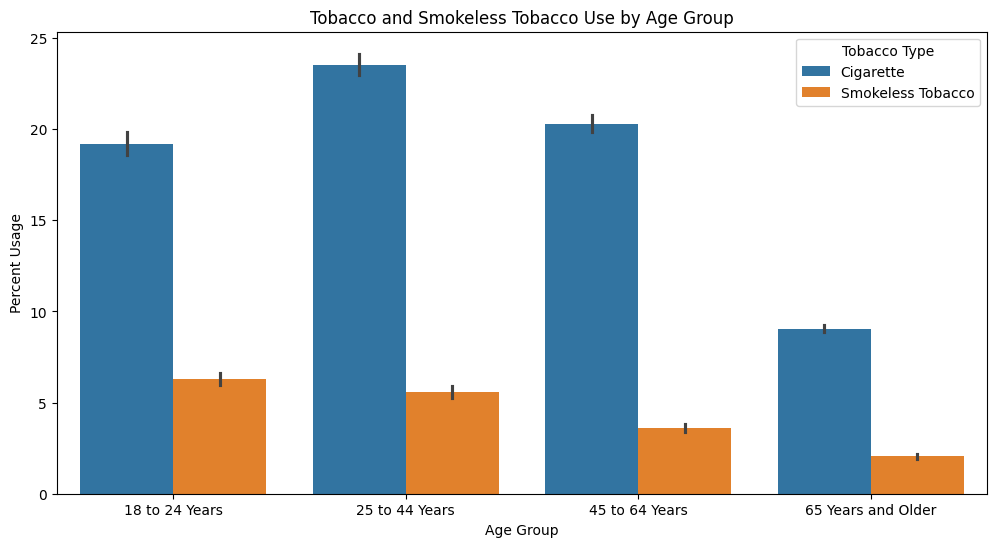

In [21]:
# How do the categories of tobacco differ in their use?
plt.figure(figsize=(12, 6))
sns.barplot(data=df_ages, x='Age', y='Percent_Usage', hue='Tobacco_Type')
plt.xlabel('Age Group')
plt.ylabel('Percent Usage')
plt.title('Tobacco and Smokeless Tobacco Use by Age Group')
plt.legend(title='Tobacco Type')
plt.show()

We can clearly observe the higher use of Cigarettes between age groups over Smokeless Tobacco Options. The visualization also displays more variability in values between Cigarette as tobacco type used percentage compared to Smokeless Tobacco. This can offer insight into data distributions and help us make predictions if different age groups have preferences in Tobacco type, the second part of our research question.

In [22]:
# We want to see tobacco types vs. age groups

df_ages[['Tobacco_Type', 'Age']].value_counts()

Tobacco_Type       Age               
Cigarette          18 to 24 Years        318
                   25 to 44 Years        318
                   45 to 64 Years        318
                   65 Years and Older    318
Smokeless Tobacco  18 to 24 Years        318
                   25 to 44 Years        318
                   45 to 64 Years        318
                   65 Years and Older    318
Name: count, dtype: int64

<Axes: xlabel='Tobacco_Type', ylabel='Percent_Usage'>

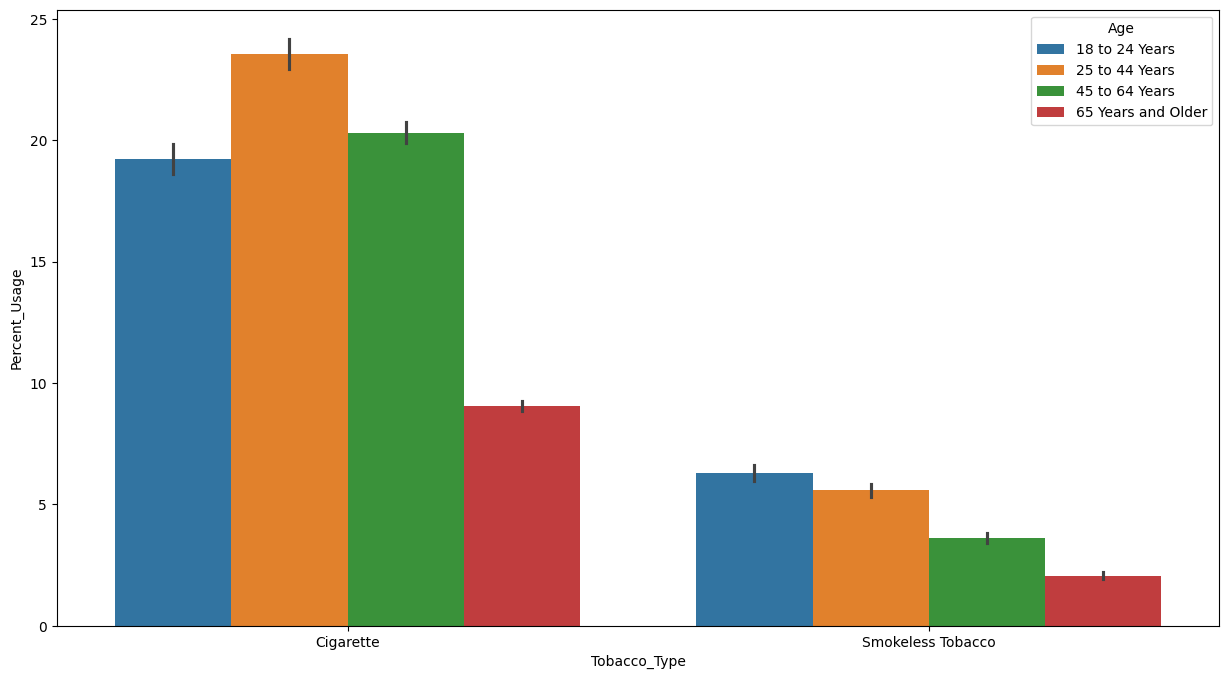

In [23]:
plt.figure(figsize = (15, 8))

sns.barplot(data = df_ages, x = 'Tobacco_Type', y = 'Percent_Usage', hue = 'Age', palette = "tab10")

# Results

## Exploratory Data Analysis

- What distributions do your variables take?
- Are there any outliers?
- Relationship between variables?
(IS THIS QUESTION SECTION ABOVE NEEDED?)

The question we will aim to answer through this method is based on the first part of our research question: 'Does Tobacco consumption change by age?'
The first step is to establish our null and alternate hypothesis. 

We start with exploratory plots. These can help hint for the presence of relationships between our studied topics, before we start our tests to find if there is indeed a relationship.

## Outliers check

In [24]:
df.head()

,Year,State,Tobacco_Type,Percent_Usage,Age
0,2011,Alabama,Cigarette,30.3,18 to 24 Years
1,2011,Alabama,Cigarette,28.2,25 to 44 Years
2,2011,Alabama,Cigarette,26.2,45 to 64 Years
3,2011,Alabama,Cigarette,10.2,65 Years and Older
4,2011,Alabama,Cigarette,24.3,All Ages


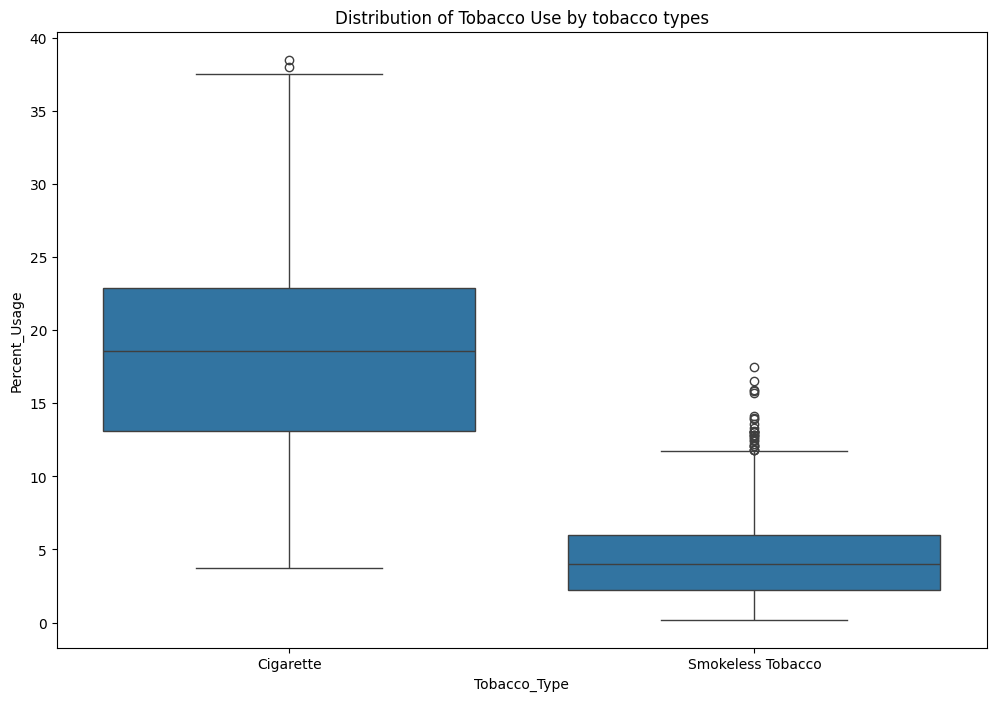

In [25]:
# boxplot displaying the percent usage in terms of tobacco types
plt.figure(figsize = (12, 8));
sns.boxplot(data=df, y = 'Percent_Usage', x = 'Tobacco_Type');
plt.title('Distribution of Tobacco Use by tobacco types');

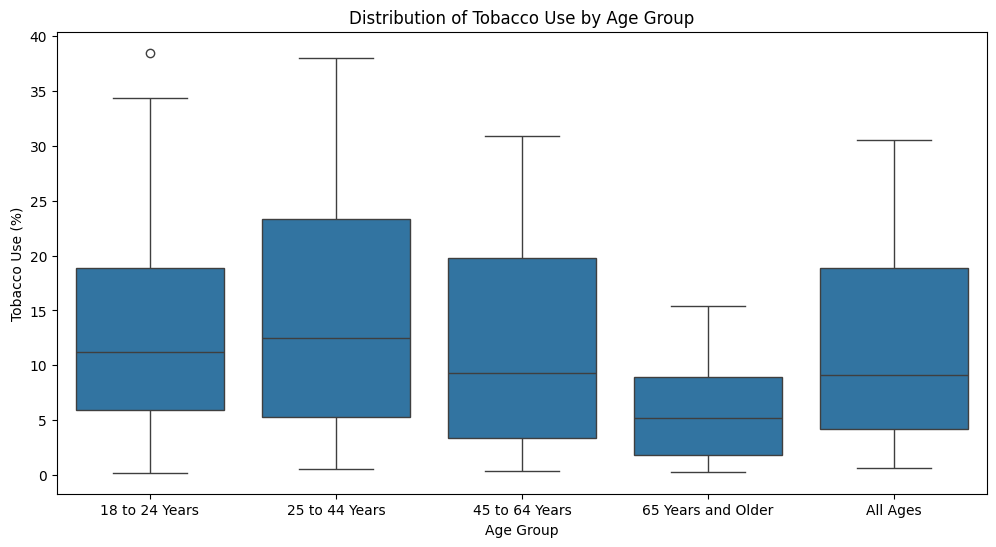

In [26]:
#Boxplots with error bars allow to fully understand the ranges in values and 
#try to account for variability produced by outliers. 

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Age', y='Percent_Usage')
plt.xlabel('Age Group')
plt.ylabel('Tobacco Use (%)')
plt.title('Distribution of Tobacco Use by Age Group')
plt.show()

In [27]:
df[df['Age'] == '18 to 24 Years'][df['Percent_Usage'] > 35]

C:\Users\carls\AppData\Local\Temp\ipykernel_23176\621909307.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[df['Age'] == '18 to 24 Years'][df['Percent_Usage'] > 35]


,Year,State,Tobacco_Type,Percent_Usage,Age
501,2011,West Virginia,Cigarette,38.5,18 to 24 Years


We can see from the plots that despite there are some datapoints have higher percent usage in terms of tobacco types or by age groups than the rest of majority, such as the region of West Virginia has a 38.5% of group 18 to 24 years are tobacco users. In considering the values of outliers are not extreme, we decide to retain the information in our analysis.

In addition, we can see the plot of Distribution of Tobacco Use by tobacco types shows very distinct Medians, IQRs, and error bars. On the other hand, from the plot of Distribution of Tobacco Use by Age Groups: while the Medians and IQRs are close, the error bars show lots of overlap and underline why the test is needed. 

## Methods for analyzing data

- **Simple Linear Regression**
- **Peearson Correlation**
- **Difference in means (t-tests)**

### **Section 1 of EDA: Linear Regression**

We can start analyzing for inference through a simple linear regression. The question we will aim to answer through this method is based on the first part of our research question: 'Does Tobacco consumption change by age?' The first step is to establish our null and alternate hypothesis.

𝐻𝑜
 : There has been no change in the trends of tobacco consumption and ages of consumption (𝛽=0
)

𝐻𝑎
: There is statistically significant change in trends of tobacco consumption and ages of consumption (𝛽≠0
)

We start with exploratory plots. These can help hint for the presence of relationships between our studied topics, before we start our tests to find if there is indeed a relationship. The above boxplot allows predictions to the OLS Regression Analysis.

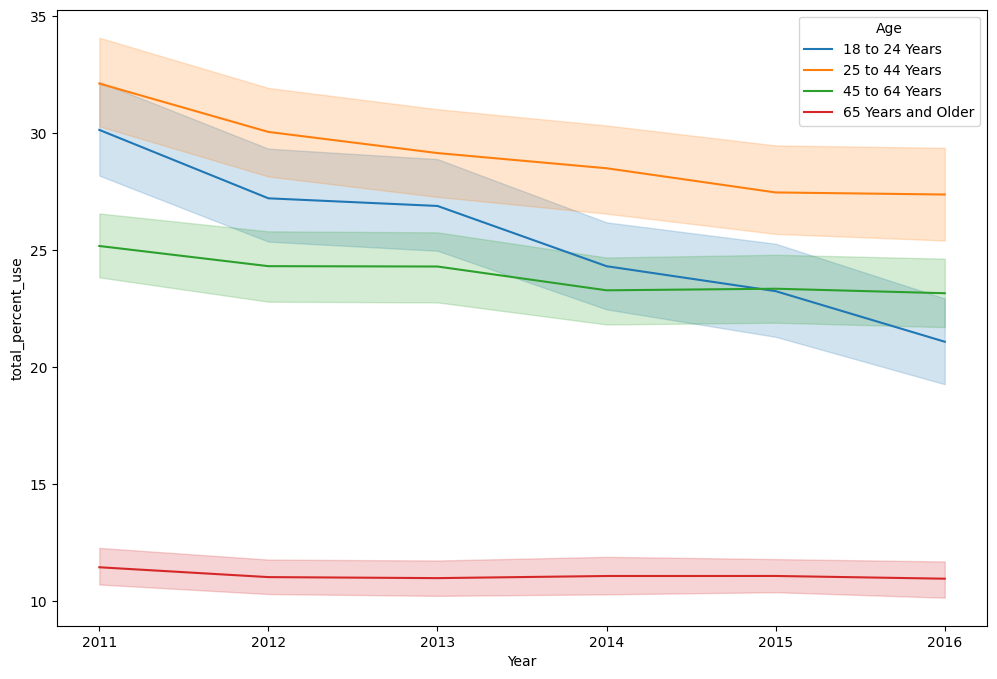

In [28]:
# Is there a correlation between age group and tobacco use?
# Lineplot allows to explore patterns by category over time and superpose values. 

plt.figure(figsize = (12, 8));

sns.lineplot(data = df_smoker, x = 'Year', y = 'total_percent_use', hue = 'Age');

We can see from the plot that from 2011 to 2016, percentages of tobacco users across age groups under 65 generally decreases. While percentages of tobacco users that are 65 year and order are the lowest and do not fluctuate much.

Next, to perform linear regression we will need patsy to establish the predictor and outcome we will be testing for. 

In [29]:
# We can specify our model matrix using `pastsy`.
# outcome = Percentage of Tobacco product usage
# predictor = Age and Tobacco type as outcomes

outcome, predictors = patsy.dmatrices('Percent_Usage ~ Age + Tobacco_Type', df)
model = sm.OLS(outcome, predictors)

In [30]:
# This code performs an ordinary least squares (OLS) regression using statsmodels to 
# analyze the relationship between the percent usage of tobacco (Percent_Usage) and 
# the predictors Age and Tobacco_Type.


results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:          Percent_Usage   R-squared:                       0.783
Model:                            OLS   Adj. R-squared:                  0.782
Method:                 Least Squares   F-statistic:                     2288.
Date:                Wed, 20 Mar 2024   Prob (F-statistic):               0.00
Time:                        13:02:57   Log-Likelihood:                -8930.0
No. Observations:                3186   AIC:                         1.787e+04
Df Residuals:                    3180   BIC:                         1.791e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

We can then focus on the following values for the interpretation of results:

- `coef` : $\beta_1$ estimate explaining the effect size of the independent variables - for Age group 25-44 (and all other groups stay constant) there is a percent of use increase approximately 1.8148.
- `std err` : standard error - Accuracy of the coefficient estimates. Smaller std err suggest more reliable estimates. Considering all values are =< 0.224 we can conclude these estimates are reliable
- `P>|t|` : the p-value - Significance of the coefficients. A p-value less than 0.05 suggests that the coefficient is statistically significant and all observed values are smaller than 0.05

$$outcome = \beta_0 + \beta_1*predictor$$

$$ Percent.Usage = 19.67 - 1.0679  * (Age + Tobacco Type) $$

A boxplot can next be made to display the model fit line and compare it to our given distribution of each tobacco type use by age group.

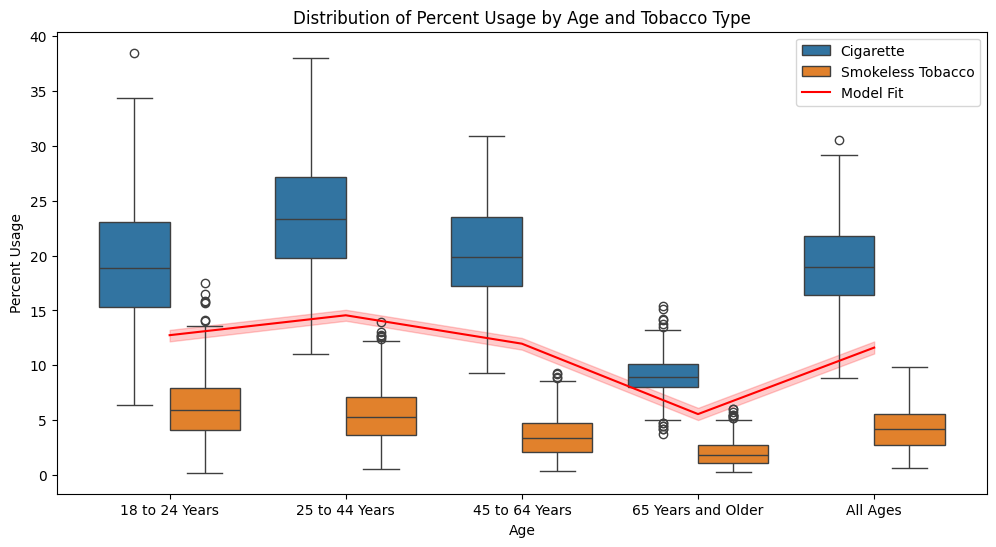

In [31]:
#We can make a boxplot displaying the differences in use between Cigarette use, Smokeless Tobacco use
#The model fit line visualizes general trends between both tobacco type uses between age groups
#Useful in visualizing the mathematical relationship between percentages of use and age groups

plt.figure(figsize=(12, 6))
sns.boxplot(x='Age', y='Percent_Usage', hue='Tobacco_Type', data=df)
sns.lineplot(x='Age', y=results.fittedvalues, color='red', label='Model Fit', data=df)
plt.title('Distribution of Percent Usage by Age and Tobacco Type')
plt.xlabel('Age')
plt.ylabel('Percent Usage')
plt.legend()
plt.show()

In [32]:
# An even more appropriate model would be a scatterplot with a model fit line
# We must define upper and lower limits to then find the average age and produce the scatter plot
# The scatterplot needs numerical categories so we convert age groups into lower and upper bound ranges


df['Age_Lower'] = df['Age'].apply(lambda x: x.split()[0] if x != 'All Ages' else '0')
df['Age_Upper'] = df['Age'].apply(lambda x: x.split()[2] if x != 'All Ages' else '100')

# Convert 'Age_Lower' and 'Age_Upper' to numeric types
df['Age_Lower'] = pd.to_numeric(df['Age_Lower'], errors='coerce')
df['Age_Upper'] = pd.to_numeric(df['Age_Upper'], errors='coerce')

# Fill NaN values with appropriate values
# We know 100 is the max age value in the dataset
df['Age_Lower'] = df['Age_Lower'].fillna(0)
df['Age_Upper'] = df['Age_Upper'].fillna(100)

(df[['Age', 'Age_Lower', 'Age_Upper']].head())

,Age,Age_Lower,Age_Upper
0,18 to 24 Years,18,24.0
1,25 to 44 Years,25,44.0
2,45 to 64 Years,45,64.0
3,65 Years and Older,65,100.0
4,All Ages,0,100.0


In [33]:
# We are exploring the values across age groups so we must remove the 'All Ages category'

df = df[df['Age'] != 'All Ages']

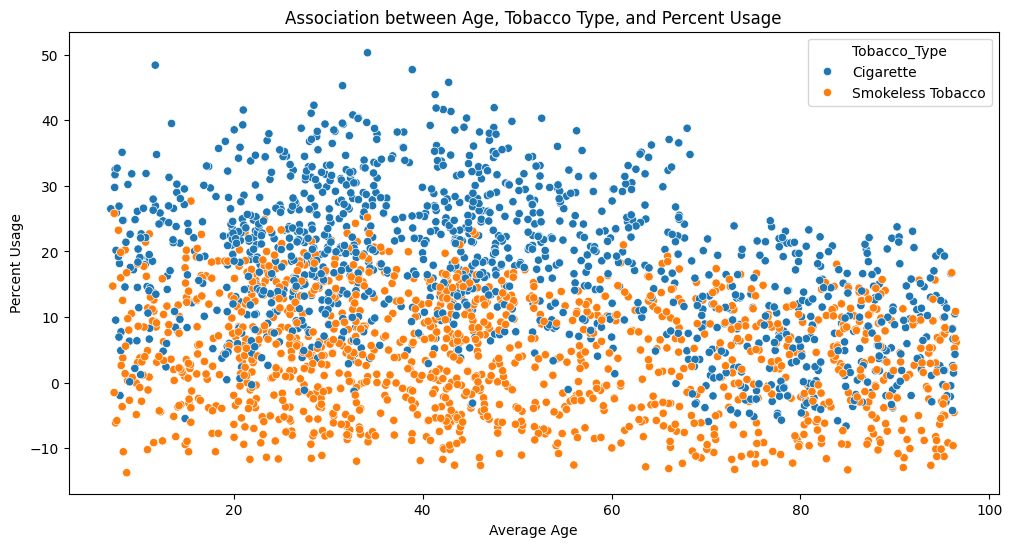

C:\Users\carls\AppData\Local\Temp\ipykernel_23176\2158424388.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_range = model.params[0] + model.params[1] * x_range


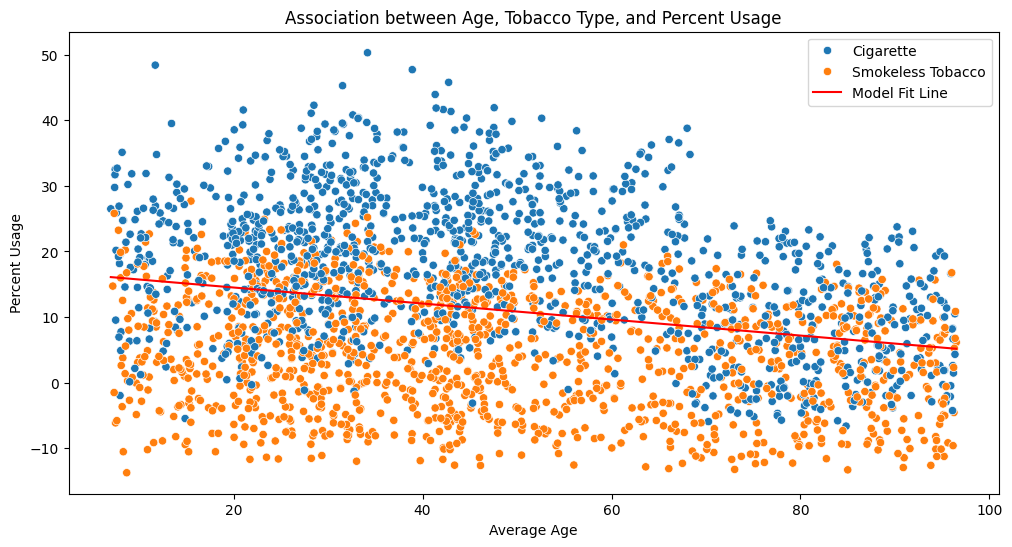

In [34]:
# Average age
df['Age_Avg'] = (df['Age_Lower'] + df['Age_Upper']) / 2

# Add jitter to the data to make the scatterplot more observable
jitter_amount = 14  
df_jittered = df.copy()
df_jittered['Age_Avg'] += np.random.uniform(-jitter_amount, jitter_amount, size=len(df))
df_jittered['Percent_Usage'] += np.random.uniform(-jitter_amount, jitter_amount, size=len(df))

# Scatter plot with jitter
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Age_Avg', y='Percent_Usage', hue='Tobacco_Type', data=df_jittered)
plt.title('Association between Age, Tobacco Type, and Percent Usage')
plt.xlabel('Average Age')
plt.ylabel('Percent Usage')
plt.show()

model = sm.OLS(df_jittered['Percent_Usage'], sm.add_constant(df_jittered['Age_Avg'])).fit()

# Model fit line
x_range = np.linspace(df_jittered['Age_Avg'].min(), df_jittered['Age_Avg'].max(), 100)
y_range = model.params[0] + model.params[1] * x_range

# Scatter plot with jitter and Model fit line
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Age_Avg', y='Percent_Usage', hue='Tobacco_Type', data=df_jittered)
plt.plot(x_range, y_range, color='red', label='Model Fit Line')
plt.title('Association between Age, Tobacco Type, and Percent Usage')
plt.xlabel('Average Age')
plt.ylabel('Percent Usage')
plt.legend()
plt.show()

The model (the line) mathematically describes the relationship between the data points for trends of Tobacco use across average age in groups, in which a rather smooth slope of the model fit line indicates a small effect size of age groups over their corresponding percent usage.

We can thus REJECT the null hypothesis:

REJECTED HYPOTHESIS - $H_o$: There has been no change in the trends of tobacco consumption and ages of consumption ($\beta = 0$)

### **Section 2 of EDA: Correlation, Pearson correlation ($r$)**

We underline the Pearson correlation as it is used in measuring the strength of association for our previous test: Age and Tobacco Consumption. As  𝑟
  approaches  |1|
 , x and y are highly correlated but values can be anywhere from -1:1

Assumptions for a Pearson correlation:
- Absence of outliers: Outliers were deemed not sufficiently significant for test disruption and retained in the data, to be treated as regular data and leaving no significant outliers. 
- Continuity and linearity: Data are linear and continuous. Our data is tobacco product percentage of use across States through variying age groups defined by upper and lower bounds. The data is unrounded and is continuous.

In [35]:
df.corr(numeric_only=True)

,Year,Percent_Usage,Age_Lower,Age_Upper,Age_Avg
Year,1.000000e+00,-0.075868,-1.487553e-15,-3.601368e-15,-1.720055e-15
Percent_Usage,-7.586785e-02,1.000000,-3.476605e-01,-3.404972e-01,-3.442216e-01
Age_Lower,-1.487553e-15,-0.347660,1.000000e+00,9.891624e-01,9.960299e-01
Age_Upper,-3.601368e-15,-0.340497,9.891624e-01,1.000000e+00,9.983056e-01
Age_Avg,-1.720055e-15,-0.344222,9.960299e-01,9.983056e-01,1.000000e+00


In [36]:
# Calculate Pearson correlation coefficient for percent usage of both tobacco types and average age. 
import scipy.stats as stats

corr, p_value = pearsonr(df['Age_Avg'], df['Percent_Usage'])

print(f"Pearson Correlation Coefficient: {corr}")
print(f"P-value: {p_value}")

Pearson Correlation Coefficient: -0.3442215705933634
P-value: 1.1116873765563698e-71


The low r value of -0.34 for the Pearson correlation measure shows there is little correlation between average age and percentage of use of tobacco products. However, our previous test showed rejected hypothesis for the null and a coefficient of determination $R^2$ value of 0.78 meaning the independent variable does a good job of explaining the variance in the dependent. This leads us to predict that while there is little correlation for age and general tobacco consumption, there is a far likelier relationship between age and non-random consumption of different types of Tobacco products. 

### **Section 3 of EDA: Difference in means: student's t-test**

The t-test tests for a difference in means between groups. It will be used to test for the prediction made above. 

$H_0: \bar x = \bar y$

$H_a: \bar x \ne \bar y$

Before performing the t-test we can verify the necessary assumptions:
- Data are continuous: Our data is a column of cigarette and smokeless tobacco use by percentage across States. The data is rounded to the nearest first decimal and is continuous
- Normal Distribution: A Shapiro-Wilk test shows a p-value < 0.01 for both Cigarette and Smokeless Tobacco: the assumption is met
- Our sample size is sufficiently large n(total) = 3186

In [37]:
# Filter the data for cigarettes and smokeless tobacco into two different dataframes
df_cigarette = df[df['Tobacco_Type'] == 'Cigarette']
df_smokeless = df[df['Tobacco_Type'] == 'Smokeless Tobacco']

# Perform t-test for each age group to see relationships of age and tobacco use by tobacco type
age_groups = df['Age'].unique()
for age_group in age_groups:
    data_cigarette = df_cigarette[df_cigarette['Age'] == age_group]['Percent_Usage']
    data_smokeless = df_smokeless[df_smokeless['Age'] == age_group]['Percent_Usage']

#t-test performed    
    t_stat, p_value = stats.ttest_ind(data_cigarette, data_smokeless, equal_var=False)
    
    print(f"T-Test Results for Age Group {age_group}:")
    print(f"T-statistic: {t_stat}")
    print(f"P-value: {p_value}")
    if p_value < 0.05:
        print("Conclusion: Reject null hypothesis (significant difference)")
    else:
        print("Conclusion: Fail to reject null hypothesis (no significant difference)")
    print()

T-Test Results for Age Group 18 to 24 Years:
T-statistic: 36.283297298707815
P-value: 1.7387102377373896e-140
Conclusion: Reject null hypothesis (significant difference)

T-Test Results for Age Group 25 to 44 Years:
T-statistic: 53.337568601565785
P-value: 1.3714746115902312e-202
Conclusion: Reject null hypothesis (significant difference)

T-Test Results for Age Group 45 to 64 Years:
T-statistic: 63.90570366340857
P-value: 6.155974898111778e-227
Conclusion: Reject null hypothesis (significant difference)

T-Test Results for Age Group 65 Years and Older:
T-statistic: 54.63716210571176
P-value: 4.985134240368301e-224
Conclusion: Reject null hypothesis (significant difference)



Our prediction is confirmed: Because all age groups display a p-value significantly smaller than 0.05, there is a significant difference in use of differing tobacco products for various age groups and the age group choices of tobacco products are non-random as the null hypothesis for the t-test can be rejected

# Ethics & Privacy

The CDC’s multilevel regression and poststratification (MRP) approach<a name="cite_ref-5"></a>[<sup>5</sup>](#cite_note-5) addresses several biases by linking geocoded health surveys with detailed demographic and socioeconomic data. This dataset has data for all ages that are above 18, which helps in adjusting for biases that might arise from overlooking the age attribute. In terms of data privacy, As we examine the data, we can be sure that individual privacy and sensitive information are not subject to exposure in this research because each datapoint is US state specific and does not have personally identifiable information, reducing privacy risks. The dataset also provides data of all US states, which allows us to have a better understanding of tobacco consumption across different communities. This prevents us from stigmatizing individual groups.

The dataset utilized for our research originates from the CDC Behavioral Risk Factor Surveillance System (BRFSS)<a name="cite_ref-6"></a>[<sup>6</sup>](#cite_note-6), a reputable survey capturing insights into tobacco consumption patterns across 54 states and territories in the US. Notably, these territories lack clinical data and are therefore exempt from the regulations imposed by the Health Insurance Portability and Accountability Act (HIPAA). It's crucial to highlight that the data collected via BFRSS is anonymized and falls outside the purview of HIPAA-covered entities. Consequently, there's no requirement to seek ethical approval for our research. Spanning from 2011 to 2016, the dataset enables an examination of trends in tobacco usage, considering the evolving societal norms, legislative changes, and shifts in tobacco product availability over the specified timeframe. It is crucial to adjust for biases. 

As we come up with our research question and hypothesis, we are careful not to direct our viewpoint to a specific US state, and focus on discussing a potential correlation over a scenario generally to prevent us from biased perspectives or violation of ethical guidelines.

We will also ensure that during our process of data analysis and modeling, we will continuously communicate the importance of limiting data bias (including stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables), considering missing perspectives, honest representation of the underlying data, and other aspects valued in the ethics checklist.

# Discussion and Conclusion
We were able to work together as a team to accomplish the goals of our project this quarter. We were able to follow the timeline proposal and perform data science techniques. 

The analysis of U.S. tobacco use from 2011 to 2016 underscores a persistent preference for cigarettes across age demographics, despite public health efforts. Statistically significant age-specific trends emerge from the data: Young adults (18 to 24) are showing a notable decline in usage, potentially reflecting the impact of health education campaigns. Meanwhile, individuals over 65 are also using tobacco less, which might be attributed to generational attitude shifts, health repercussions, or increased health awareness post-retirement. 

The overall pattern, as suggested by a mild inverse correlation (-0.344) between average age and tobacco use, indicates a general decline in usage with increasing age—albeit with pronounced age-specific behaviors. However, it is important to note that age is not a leading factor in determining tobacco usage. The t-test validations indicate that age significantly influences tobacco preferences, pointing to a nuanced relationship between age brackets and tobacco product choice.

In terms of product types, while cigarettes dominate, smokeless tobacco maintains a notable market share. This enduring usage, especially in certain regions or subcultures, highlights the need for targeted public health strategies to dispel misconceptions about smokeless tobacco's risks. The findings call for sustained and tailored public health initiatives to further decrease tobacco consumption across all age groups.

Our research faces several limitations. The dataset, sourced from the CDC's Behavioral Risk Factor Surveillance System (BRFSS) and covering 54 states and territories, may not fully capture subtle local patterns of tobacco use due to regional variations in data collection methods. These variations could impact the accuracy of our regression analysis, making it challenging to generalize our findings to specific locales. Additionally, the lack of clinical data prevents a direct correlation between self-reported tobacco usage and health outcomes. The dataset's scope, extending only to 2016, does not reflect recent public health initiatives, regulatory changes, or the introduction of new products. Consequently, while our findings offer valuable insights up to 2016, the evolving landscape of tobacco use necessitates updated research to grasp its current state and implications for public health.

The impact of our project, which investigates the relationship between age groups and tobacco usage in the U.S. from 2011 to 2016, extends across several domains:
1. Public Health Impact : Data showing a decline in tobacco use among seniors and possibly young adults may support continued funding and development of age-targeted smoking cessation programs and policies.
2. Policy and Legislative Impact: The results can be used to support legislation limiting the marketing of tobacco products, especially those that target particular age groups. The information might promote the creation of laws that support age-specific initiatives, including prohibiting the sale of tobacco products close to schools in order to avoid harming younger people.
3. Scientific and Research Impact: Planning and resource allocation for public health may now be based on data, thanks to the project's findings.
4. Socio Economic Impact: Reducing tobacco use can save long-term medical expenses by lowering the prevalence of diseases linked to tobacco use. Additionally focusing on midlife adults when it comes to tobacco cessation can increase productivity by lowering health problems associated with smoking that cause absenteeism.


# Team Contributions

Most of our group meetings were done online via Discord. As a group, we feel that everyone contributed equally to our project's completion. The data cleaning was performed by Yu. Following the data cleaning, the EDA and data analysis was performed by Emre and Carlson. Annie and Safia worked on the ethics and privacy section as well as the writing portions. All group members contributed to each area equally. 